# Customer Retention Intelligence using Multi-Agent AI System
## Objective

In this notebook, we are going to build a Multi-Agent Customer Retention Intelligence System using LangChain & LangGraph. The system takes a Customer ID as input and uses three specialized, **tool-bound** sub-agents plus a Supervisor to profile the customer, assess churn risk, retrieve the appropriate retention strategy, and generate a structured Next Best Action (NBA) recommendation.
- **Customer Profiler Agent:** calls `fetch_customer_record_tool` to retrieve customer information and creates a profile summary.
- **Churn Diagnostician Agent:** calls `classify_risk_segment_tool` to apply deterministic business rules to classify the customer into a churn risk segment.
- **Retention Strategist Agent:** calls `recommend_retention_action_tool` to retrieve (via RAG over ChromaDB) the most appropriate retention playbook.
- **Supervisor Agent:** Coordinates the LangGraph workflow and assembles the final structured NBA recommendation from the three sub-agent's verified outputs.

Together, these agents form a modular and transparent multi-agent system that helps businesses identify at-risk customers and recommend effective retention strategies.

| S.No. | Stage | Agent | Tool | Type |
|---|---|---|---|---|
| 1 | Profile | Customer Profiler Agent | `fetch_customer_record()` | Dict lookup + LLM formatting |
| 2 | Diagnose | Churn Diagnostician Agent | `classify_risk_segment()` | Deterministic Python rules |
| 3 | Recommend | Retention Strategist Agent | `recommend_retention_action()` | RAG retrieval (ChromaDB) |
| 4 | Decide | Supervisor Agent | — | Combines verified sub-agent outputs to produce the final six-field decision |

---

## Full Architecture Diagram
<pre>

                                                    CUSTOMER RETENTION INTELLIGENCE
                                                    Input: Customer ID (e.g. "V001")
                                                                    |
                                                                    v
            +------------------------------------------------------------------------------------------------------+
            |  NODE: supervisor  (ROUTING MODE)                                                                    |
            |  +------------------------------------------------------------------------------------------------+  |
            |  |   Reads shared state. Checks which sub-agents have already run                                 |  |
            |  |   and whether their output is complete.                                                        |  |
            |  |                                                                                                |  |
            |  |   Decision Logic:                                                                              |  |
            |  |    * profiler_output missing/incomplete?  --> route to profiler                                |  |
            |  |    * diagnostician_output missing?        --> route to diagnostician                           |  |
            |  |    * strategist_output missing?           --> route to strategist                              |  |
            |  |    * ALL THREE complete?                  --> FINAL RESPONSE MODE                              |  |
            |  +------------------------------------------------------------------------------------------------+  |
            +------------------------------------------------------------------------------------------------------+
                |                                 |                                       |                    |
                | next='profiler'                 | next='diagnostician'                  | next='strategist'  | next='END'(all 3 done)
                v                                 v                                       v                    +--------------+
+--------------------------------+  +--------------------------------+  +------------------------------------------+          |
| NODE:profiler                  |  | NODE:diagnostician             |  | NODE: strategist                         |          |
|(Customer Profiler Agent)       |  |(Churn Diagnostician Agent)     |  |(Retention Strategist Agent)              |          |
|                                |  | Agent)                         |  | Agent)                                   |          |
|                                |  |                                |  |                                          |          |
| Tool:                          |  | Tool:                          |  | Tool:                                    |          |
|  fetch_customer_record(cust_id)|  |  classify_risk_segment(cust_id)|  |  recommend_retention_action(segment_name)|          |
| --> dict lookup                |  | --> DETERMINISTIC Python rules,|  | --> RAG: queries ChromaDB vector store   |          |
| --> LLM formats profile summary|  |     NOT LLM reasoning          |  |     built from retention_playbooks.json  |          |
|                                |  | --> segment,NBA, rules fired,  |  | --> reads CLV tier from profiler to pick |          |
|                                |  |     policy                     |  |      variant                             |          |
|                                |  |                                |  |                                          |          |
| MUST NOT:                      |  | MUST NOT:                      |  | MUST NOT:                                |          |
|  - invent data,                |  |  - guess segment               |  |  - override segment/decision             |          |
|  - recommend actions           |  |  - paraphrase rules            |  |  - invent steps                          |          |
|                                |  |  - recommend actions           |  |  - omit policy                           |          |
+--------------------------------+  +--------------------------------+  +------------------------------------------+          |
                |                                  |                                         |                                |
                | Loops back!                      | Loops back!                             | Loops back!                    |
                +----------------------------------+-----------------------------------------+--------------------------------+
                                                                  |
                                                                  v
                                                        Back to NODE: supervisor
                                                     (checks completeness again,
                                                      routes to next missing agent)
                                                                  |
                                                                  |
                                                     (repeats until all 3 complete)
                                                                  |
                                                                  v
                                    +----------------------------------------------------------------------+
                                    |  NODE: supervisor  (FINAL RESPONSE MODE)                              |
                                    |  +----------------------------------------------------------------+  |
                                    |  | Triggered only when profiler_output AND diagnostician_output    |  |
                                    |  | AND strategist_output are all present.                          |  |
                                    |  |                                                                 |  |
                                    |  | Combines the three sub-agent outputs into the 6-field decision: |  |
                                    |  |  - Customer ID          (from profiler)                        |  |
                                    |  |  - Risk Segment         (from diagnostician, exact name)        |  |
                                    |  |  - Next Best Action     (ESCALATE / NURTURE / HOLD)             |  |
                                    |  |  - Action Rationale     (2 sentences, cites actual signal       |  |
                                    |  |                          values from profiler output)           |  |
                                    |  |  - Treatment Steps      (1-2-3, from strategist)                |  |
                                    |  |  - Engagement Policy    (exact policy, from strategist)         |  |
                                    |  +----------------------------------------------------------------+  |
                                    +----------------------------------------------------------------------+
                                                                        |
                                                                        v
                                                            +--------------------------+
                                                            |          END             |
                                                            | (Final 6-field decision) |
                                                            +--------------------------+


</pre>

## 1. Environment Setup and imports 

### 1.1 Installing and Importing Required Libraries

In this step, all necessary libraries are installed and imported to build the multi-agent Customer Retention Intelligence System. Each library serves a specific purpose within the application architecture.

* **LangChain** provides the framework for building LLM-powered applications, managing prompts, chains, output parsing, and integrations with external tools and models.
* **LangGraph** enables the creation of stateful, multi-agent workflows by orchestrating agent interactions, routing decisions, and execution flow through graph-based architectures.
* **Azure OpenAI** supplies the Large Language Model (LLM) capabilities used by the agents for customer profiling, churn diagnosis, retention planning, and final decision generation.
* **ChromaDB** acts as the vector database for storing and retrieving retention playbooks and knowledge artifacts using semantic similarity search.
* **Pandas** is used for data ingestion, manipulation, and analysis of customer records and retention datasets.
* **Python Dotenv** securely loads environment variables such as API keys, endpoints, and configuration settings from a `.env` file, preventing sensitive information from being hardcoded into the application.

Together, these libraries provide the foundation for data processing, AI reasoning, workflow orchestration, knowledge retrieval, and secure configuration management within the agentic retention system.
thon Dotenv

In [3]:
!pip uninstall -y \
langchain \
langchain-core \
langchain-community \
langchain-openai \
langgraph \
langchain-chroma

!pip install -U \
langchain \
langchain-core \
langchain-community \
langchain-openai \
langgraph \
langchain-chroma \
langchain-text-splitters \
chromadb \
python-dotenv \
pandas

print("All packages installed!")

Found existing installation: langchain 1.4.0
Uninstalling langchain-1.4.0:
  Successfully uninstalled langchain-1.4.0
Found existing installation: langchain-core 1.6.2
Uninstalling langchain-core-1.6.2:
  Successfully uninstalled langchain-core-1.6.2
Found existing installation: langchain-community 0.4.2
Uninstalling langchain-community-0.4.2:
  Successfully uninstalled langchain-community-0.4.2
Found existing installation: langchain-openai 1.6.1
Uninstalling langchain-openai-1.6.1:
  Successfully uninstalled langchain-openai-1.6.1
Found existing installation: langgraph 1.2.11
Uninstalling langgraph-1.2.11:
  Successfully uninstalled langgraph-1.2.11
Found existing installation: langchain-chroma 1.1.0
Uninstalling langchain-chroma-1.1.0:
  Successfully uninstalled langchain-chroma-1.1.0
  Using cached langchain-1.4.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_core-1.6.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadat

In [4]:
import os
import json
import warnings
from typing import TypedDict, Optional

import pandas as pd
from dotenv import load_dotenv
from IPython.display import display, Markdown, Image

warnings.filterwarnings("ignore")

# Document loading, splitting and vector store
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# LLM + embeddings
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate

# Tool registration
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage, AIMessage

# graph orchestration
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END

print("All libraries imported successfully.")


All libraries imported successfully.


### 1.2 Load Azure OpenAI Credentials

To access Azure OpenAI services, all model endpoints, deployment names, API keys, and configuration settings are stored securely in the `.env` file. This approach helps protect sensitive credentials and simplifies environment management across development and deployment environments.

The following configuration values are required:

* **MODEL\_ENDPOINT**: Azure OpenAI endpoint for the chat model deployment.
* **CHAT\_MODEL\_NAME**: Name of the deployed chat model used for conversational interactions.
* **AZURE\_OPENAI\_API\_KEY**: Authentication key for accessing Azure OpenAI services.
* **API\_VERSION**: Azure OpenAI API version used for chat model abilities.
* **EMBEDDING\_MODEL\_NAME**: Name of the deployed embedding model used for vector generation.
* **MODEL\_ENDPOINT\_EMBEDDING**: Azure OpenAI endpoint associated with the embedding model deployment.
* **API\_VERSION\_EMBEDDING**: API version used for embedding model requests.
* **N\_EMBEDDING**: Embedding vector dimension size generated by the embedding model. This value is commonly used when configuring vector databases, similarity search, and retrieval-augmented generation (RAG) pipelines to ensure compatibility with storrch integration.


In [5]:
# Load credentials from .env file
load_dotenv('DENTSU_AZURE.env')

# Get the values from environment
ENDPOINT = os.environ.get("MODEL_ENDPOINT")
MODEL_NAME = os.environ.get("CHAT_MODEL_NAME")
API_KEY = os.environ.get("AZURE_OPENAI_API_KEY")
API_VERSION = os.environ.get("api_version")
EMBEDDINGS_MODEL = os.environ.get("EMBEDDING_MODEL_NAME")
EMBEDDINGS_MODEL_ENDPOINT = os.environ.get("MODEL_ENDPOINT_EMBEDDING")
API_VERSION_EMBEDDING = os.environ.get("api_version_embedding")

os.environ["ANONYMIZED_TELEMETRY"] = "False"

# Verify required Azure OpenAI environment settings are configured.
REQUIRED = {
    "MODEL_ENDPOINT": ENDPOINT, "CHAT_MODEL_NAME": MODEL_NAME, "AZURE_OPENAI_API_KEY": API_KEY,
    "api_version": API_VERSION, "EMBEDDING_MODEL_NAME": EMBEDDINGS_MODEL,
    "MODEL_ENDPOINT_EMBEDDING": EMBEDDINGS_MODEL_ENDPOINT, "api_version_embedding": API_VERSION_EMBEDDING,
}
missing = [k for k, v in REQUIRED.items() if not v]
if missing:
    raise EnvironmentError(f"Missing required environment variable(s): {missing}. Check DENTSU_AZURE.env")

print("Credentials loaded!")
print(f"Chat Model  : {MODEL_NAME}")
print(f"Embed Model : {EMBEDDINGS_MODEL}")

Credentials loaded!
Chat Model  : gpt-4o
Embed Model : text-embedding-ada-002


### 1.3 Create the LLM and Embedding Clients

After loading the environment variables, LLM and embedding clients are initialized using the Azure OpenAI configuration. The LLM client powers conversational reasoning, agent orchestration, and response generation, while the embedding client generates vector representations of text for semantic search and retrieval tasks. These clients serve as the foundation for all AI-powered interactions within the application.


In [6]:
# single source of truth for determinism across every agent + the judge
LLM_TEMPERATURE = 0  

# Create LangChain Chat model
llm = AzureChatOpenAI(
    azure_deployment=MODEL_NAME,
    api_version=API_VERSION,
    azure_endpoint=ENDPOINT,
    api_key=API_KEY,
    temperature=LLM_TEMPERATURE
)

assert llm.temperature == LLM_TEMPERATURE
print(f"LLM client ready (temperature={llm.temperature}).")

# Create LangChain Embeddings model
embeddings = AzureOpenAIEmbeddings(
    azure_endpoint=EMBEDDINGS_MODEL_ENDPOINT,
    azure_deployment=EMBEDDINGS_MODEL,
    openai_api_version=API_VERSION_EMBEDDING,
    api_key=API_KEY
)
print("Embeddings model ready!")

LLM client ready (temperature=0.0).
Embeddings model ready!


## 2. Dataset Loading & Understanding

This step focuses on loading, exploring, and preparing the customer datasets used by the Customer Retention Intelligence System. The data provides the customer attributes and behavioral signals required for retention analysis and decision-makinm.

* **risk\_segments.json**  
  Contains four predefined customer churn risk segments. Each segment includes the segment name, priority, signal thresholds, Next Best Action (NBA), and engagement policy. This file is used by the risk classification tool to identify the appropriate customer risk segment.

* **retention\_playbooks.json**  
  Contains four retention playbooks, one for each churn risk segment. Each playbook defines treatment steps, CLV-based modifications, escalation conditions, and engagement policies. This file is ideal for loading into a vector store and retrieving relevant playbooks using a RAG-based approach.

* **validation\_customer\_records.json**  
  Contains 10 labeled customer records used for development and evaluation. These records should be used to test, refine, and validate the behavior of the multi-agent system before running on the test dataset.

* **validation\_results.csv**  
  Provides the expected agent outputs for all validation customers. This file serves as the ground truth for performance evaluation and can be used for comparison through LLM-as-Judge evaluation and manual review.

* **test\_customer\_records.json**  
  Contains 10 unseen customer records reserved for final evaluation. Once the system is finalized, these records should be processed to generate retention recommendations and save the results in **submission.csv** for lligence system.
g.lete customer view.


### 2.1 Load Datasets
Customer records are imported into Pandas DataFrames for analysis and processing.

In [7]:
DATA_DIR = 'dentsu_genai_developer_capstone1_customer_retention_data'

# Load Risk Segments
with open(f"{DATA_DIR}/risk_segments.json","r") as f:
    risk_segments = json.load(f)

# Load Playbooks
with open(f"{DATA_DIR}/retention_playbooks.json","r") as f:
    retention_playbooks = json.load(f)

# Load Validation Customers
with open(f"{DATA_DIR}/validation_customer_records.json","r") as f:
    validation_customers = json.load(f)

# Load Test Customers
with open(f"{DATA_DIR}/test_customer_records.json","r") as f:
    test_customers = json.load(f)

# Load Validation CSV
validation_results = pd.read_csv(f"{DATA_DIR}/validation_results.csv")

print("Risk Segments :", len(risk_segments))
print("Retention Playbooks :", len(retention_playbooks))
print("Validation Customers :", len(validation_customers))
print("Test Customers :", len(test_customers))

Risk Segments : 4
Retention Playbooks : 4
Validation Customers : 10
Test Customers : 10


### 2.2 Review Sample Data
A subset of records is examined to understand the available customer attributes, data distribution, and overall dataset structure.

In [8]:
risk_segments[0]

{'id': 'RS-001',
 'priority': 1,
 'segment': 'Support-Fatigued',
 'definition': 'Customer has raised multiple support tickets recently and NPS has dropped sharply, indicating a poor service experience is actively driving churn intent.',
 'decision': 'ESCALATE',
 'required_signals': ['support_tickets >= 3',
  'nps_score <= 4',
  'email_open_rate < 0.20'],
 'engagement_policy': 'No promotional content until the service issue is confirmed resolved'}

In [9]:
retention_playbooks[0]

{'id': 'PB-001',
 'segment': 'Support-Fatigued',
 'decision': 'ESCALATE',
 'treatment_steps': ['Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) or send a personalised service recovery email within 48 hours (Silver/Bronze tier) - do not use generic automated messaging',
  "Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience",
  'Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team'],
 'escalation_condition': 'Additional support ticket lodged within 7 days of initial outreach',
 'engagement_policy': 'No promotional content until the service issue is confirmed resolved'}

In [10]:
validation_customers[0]

{'customer_id': 'V001',
 'name': 'Anjali Desai',
 'clv_tier': 'Gold',
 'recency_days': 67,
 'app_sessions_mo': 1,
 'email_open_rate': 0.1,
 'nps_score': 3,
 'support_tickets': 4}

In [11]:
val_result = validation_results.reference_agent_response[0]
print(val_result)

- Customer ID: V001
- Risk Segment: Support-Fatigued
- Next Best Action: ESCALATE
- Action Rationale: Anjali Desai has submitted 4 support tickets in the last 30 days and has a low NPS score of 3, indicating dissatisfaction. Additionally, her email open rate is only 10%, which is below the threshold of 20%.
- Treatment Steps:
  1. Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) or send a personalised service recovery email within 48 hours (Silver/Bronze tier) - do not use generic automated messaging.
  2. Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience.
  3. Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team.
- Engagement Policy: No promotional content until the service issue is confirmed resolved


### 2.3 Merge Validation and Test Records
The validation and test customer datasets are combined into a single consolidated dataset. This creates a unified customer repository that serves as the source of customer information throughout the multi-agent workflow.ID.

In [12]:
all_customers = validation_customers + test_customers

customer_lookup = {}
for customer in all_customers:
    customer_lookup[customer["customer_id"]] = customer

print("Total Customers :", len(customer_lookup))

Total Customers : 20


## 3. Customers & Knowledge base setup

### 3.1 Convert Retention Playbook Data to LangChain Documents

The retention playbook records are converted into **LangChain Documents** to make them compatible with Retrieval-Augmented Generation (RAG). This transformation enables the retention knowledge to be indexed, searched, and retrieved dynamically based on customer risk segments plan. plan.
AG).

In [13]:
playbook_documents = []
for playbook in retention_playbooks:
    text = f"""
    Segment: {playbook['segment']}
    Decision: {playbook['decision']}
    Treatment Steps: {playbook['treatment_steps']}
    Escalation Condition: {playbook['escalation_condition']}
    Engagement Policy: {playbook['engagement_policy']}
    """

    playbook_documents.append(
        Document(
            page_content=text,
            metadata={
                "id": playbook["id"],
                "segment": playbook["segment"],
                "decision": playbook["decision"]
            }
        )
    )

print(f"Created {len(playbook_documents)} campaign documents")

Created 4 campaign documents


In [14]:
playbook_documents[0]

Document(metadata={'id': 'PB-001', 'segment': 'Support-Fatigued', 'decision': 'ESCALATE'}, page_content='\n    Segment: Support-Fatigued\n    Decision: ESCALATE\n    Treatment Steps: [\'Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) or send a personalised service recovery email within 48 hours (Silver/Bronze tier) - do not use generic automated messaging\', "Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer\'s patience", \'Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team\']\n    Escalation Condition: Additional support ticket lodged within 7 days of initial outreach\n    Engagement Policy: No promotional content until the service issue is confirmed resolved\n    ')

### 3.2 Store in ChromaDB and Create Retriever

The LangChain Documents are embedded and stored in **ChromaDB**, creating a searchable retention knowledge base. A **Retriever** is then configured on top of the vector store, allowing the Retention Strategist Agent to perform semantic search and retrieve the most relevant playbook before generating a personalized retention treatment plan.plan.


In [15]:
# Creating ChromaDB
PERSIST_DIR_PLAYBOOK = "retention_playbooks_db_vectorstore"

if os.path.exists(PERSIST_DIR_PLAYBOOK):
    vectordb_playbook = Chroma(
        collection_name = "retention_playbooks_db",
        persist_directory = PERSIST_DIR_PLAYBOOK,
        embedding_function = embeddings,
    )
    print(f"Loaded existing vector store from {PERSIST_DIR_PLAYBOOK}")
else:
    vectordb_playbook = Chroma.from_documents(
        documents = playbook_documents,
        collection_name = "retention_playbooks_db",
        persist_directory = PERSIST_DIR_PLAYBOOK,
        embedding = embeddings,
    )
    print(f"Created and saved vector store to {PERSIST_DIR_PLAYBOOK}")
print(f"Vector store ready with {vectordb_playbook._collection.count()} segments!")

Loaded existing vector store from retention_playbooks_db_vectorstore
Vector store ready with 4 segments!


In [16]:
# Create retriever
retriever_playbook = vectordb_playbook.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.5, "k": 5}
)
print(f"Retention playbooks retriever ready!")

Retention playbooks retriever ready!


## 4. Tool implementations

### 4.1 Tool 1: `fetch_customer_record()`

This tool retrieves customer information from the consolidated customer dataset using the provided **Customer ID**. The raw customer record is then passed to an LLM-powered formatting prompt, which converts the data into a structured and standardized customer summarion.

**Output:** A formatted customer summary including Customer ID, Name, CLV Tier, Recency, App Sessions, Email Open Rate, NPS Score, and Support Ticket inform

This structured output serves as the input for the **Customer Profiler Agent**, enabling subsequent agents to make informed retention decisions.ation.


In [17]:
FETCH_CUSTOMER_RECORD_PROMPT = ChatPromptTemplate.from_messages(
    [("system","""
You are a Customer Data Formatter.

RESPONSIBILITY:
Convert a raw customer record into a structured customer summary.

MANDATORY RULES:
1. Use every field provided.
2. Do not invent values.
3. Do not infer missing values.
4. Do not provide recommendations.
5. Do not classify risk.
6. Only present the customer data clearly.

OUTPUT FORMAT:

**Customer Summary**
- **Customer ID:** [value]
- **Name:** [value]
- **CLV Tier:** [value]
- **Recency (days since last purchase):** [value]
- **App Sessions / Month:** [value]
- **Email Open Rate:** [value]
- **NPS Score (out of 10):** [value]
- **Support Tickets (last 30 days):** [value]

Return only the specified format.
"""), 
     ("human", """
Raw Customer Record:
{customer_record}
"""
),]
)

In [22]:
@tool
def fetch_customer_record(customer_id: str) -> str:
    """
    Retrieve a customer record for the specified customer ID and generate
    a structured customer profile summary for downstream agent analysis.

    Args:
        customer_id: Unique customer identifier.

    Returns:
        JSON string containing the customer record, formatted profile summary,
        retrieval status, and associated metadata.
    """
    customer = customer_lookup.get(customer_id)
    if customer is None:
        return json.dumps({
            "tool_name": "fetch_customer_record",
            "found": False,
            "customer_id": customer_id,
            "error": f"No customer record found for ID '{customer_id}' in the merged customer pool.",
        })

    # LLM Formatting
    chain = FETCH_CUSTOMER_RECORD_PROMPT | llm
    response = chain.invoke({"customer_record": customer})
    formatted_summary = response.content
    
    return json.dumps({
        "tool_name": "fetch_customer_record",
        "found": True,
        "customer_id": customer["customer_id"],
        "raw_record": customer,
        "formatted_summary": formatted_summary,
    })


In [23]:
# Quick sanity check of the tool direct call
customer_record = fetch_customer_record.invoke({"customer_id": "V001"})
customer_record

'{"tool_name": "fetch_customer_record", "found": true, "customer_id": "V001", "raw_record": {"customer_id": "V001", "name": "Anjali Desai", "clv_tier": "Gold", "recency_days": 67, "app_sessions_mo": 1, "email_open_rate": 0.1, "nps_score": 3, "support_tickets": 4}, "formatted_summary": "**Customer Summary**\\n- **Customer ID:** V001\\n- **Name:** Anjali Desai\\n- **CLV Tier:** Gold\\n- **Recency (days since last purchase):** 67\\n- **App Sessions / Month:** 1\\n- **Email Open Rate:** 0.1\\n- **NPS Score (out of 10):** 3\\n- **Support Tickets (last 30 days):** 4"}'

In [24]:
Markdown(json.loads(customer_record)["formatted_summary"])

**Customer Summary**
- **Customer ID:** V001
- **Name:** Anjali Desai
- **CLV Tier:** Gold
- **Recency (days since last purchase):** 67
- **App Sessions / Month:** 1
- **Email Open Rate:** 0.1
- **NPS Score (out of 10):** 3
- **Support Tickets (last 30 days):** 4

### 4.2 Tool 2: `classify_risk_segment()`

This tool identifies a customer's churn risk segment by evaluating their signals against the predefined rules in **risk\_segments.json**. Once a matching segment is found, it returns the risk segment, Next Best Action (NBA), engagement policy, and the specific rules that triggered the classification.

The output is used by the **Churn Diagnostician Agent** to determine the customer's risk level and recommended action.


In [25]:
@tool
def classify_risk_segment(customer_id: str) -> str:
    """Classify a customer into a churn-risk segment using deterministic,
    priority-ordered business rules defined in risk_segments.json.

    Args:
        customer_id: Unique customer identifier (for example, 'V001').

    Returns:
        JSON string containing the risk segment, next best action,
        engagement policy, triggered rules, and diagnostic metadata.
    """
    customer = customer_lookup.get(customer_id)
    if customer is None:
        return json.dumps({
            "tool_name": "classify_risk_segment", 
            "found": False, 
            "customer_id": customer_id,
            "error": f"No customer record found for ID '{customer_id}'.",
        })

    for segment in risk_segments:
        condition = " and ".join(segment["required_signals"])
        if eval(condition, {}, customer):
            rules_fired = [
                f"{rule} — actual: {customer[rule.split()[0]]}"
                for rule in segment["required_signals"]
            ]
            return json.dumps({
                "tool_name": "classify_risk_segment", 
                "found": True, 
                "customer_id": customer_id,
                "segment": segment["segment"], 
                "decision": segment["decision"],
                "definition": segment["definition"], 
                "engagement_policy": segment["engagement_policy"],
                "rules_fired": rules_fired,
            })

    return json.dumps({
        "tool_name": "classify_risk_segment", 
        "found": False, 
        "customer_id": customer_id,
        "error": f"No risk segment matched customer '{customer_id}' against any of the {len(risk_segments)} deterministic rule sets."
    })


In [26]:
classify_risk_segment.invoke('V001')

'{"tool_name": "classify_risk_segment", "found": true, "customer_id": "V001", "segment": "Support-Fatigued", "decision": "ESCALATE", "definition": "Customer has raised multiple support tickets recently and NPS has dropped sharply, indicating a poor service experience is actively driving churn intent.", "engagement_policy": "No promotional content until the service issue is confirmed resolved", "rules_fired": ["support_tickets >= 3 \\u2014 actual: 4", "nps_score <= 4 \\u2014 actual: 3", "email_open_rate < 0.20 \\u2014 actual: 0.1"]}'

### 4.3 Tool 3: `recommend_retention_action()`

This tool retrieves the most relevant retention playbook from the **ChromaDB** knowledge base using the customer's risk segment. The retrieved playbook is then formatted into a clean, business-friendly structure containing the segment, decision, treatment steps, escalation condition, and engagement policy.

The output is used by the **Retention Strategist Agent** to generate a structured retention treatment plan aligned with the organization's predefined playbooks and policies.


In [27]:
RECOMMEND_RETENTION_ACTION_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """
You are a playbook formatter.
Your task is to convert LangChain Document objects into a clean business-readable format.

For each document:
- Extract Playbook ID from metadata.id
- Extract Segment and Decision
- Convert Treatment Steps into a numbered list
- Remove Python list syntax, quotes, brackets, and escape characters
- Preserve the original text
- Return one formatted block per playbook

Output format:
Playbook ID: <ID>
Playbook Content:
Segment: <SEGMENT>
Decision: <DECISION>
Treatment Steps:
    1. <STEP_1>
    2. <STEP_2>
    3. <STEP_3>
Escalation Condition: <ESCALATION_CONDITION>
Engagement Policy: <ENGAGEMENT_POLICY>

Do not return:
- Document()
- metadata=
- page_content=
- JSON
- Python lists
- Markdown code blocks
- Any explanations

Only return the formatted playbooks.
"""), ("human", """
    Playbook:
    {playbook}
""")]
)

In [28]:
@tool
def recommend_retention_action(segment_name):
    """
    Retrieve and format the most appropriate retention playbook 
    for a given churn risk segment.
    The function performs a semantic search against the ChromaDB knowledge base,
    retrieves the relevant retention playbook, and uses an LLM to convert the retrieved document
    into a structured, business-friendly retention strategy.
    """
    docs = retriever_playbook.invoke(segment_name)
    if not docs:
        return "Playbook Not Found"
    chain = RECOMMEND_RETENTION_ACTION_PROMPT | llm
    response = chain.invoke({'playbook': docs[0]})
    
    playbook = docs[0].page_content
    formatted_recommendation = response.content
    matched_id = docs[0].metadata["id"]
    
    return json.dumps({
        "tool_name": "recommend_retention_action", 
        "found": True, 
        "segment_name": segment_name,
        "matched_playbook_id": matched_id, 
        "raw_playbook": playbook,
        "formatted_recommendation": formatted_recommendation,
    })

In [29]:
recommend_retention_action.invoke("Support-Fatigued")

'{"tool_name": "recommend_retention_action", "found": true, "segment_name": "Support-Fatigued", "matched_playbook_id": "PB-001", "raw_playbook": "\\n    Segment: Support-Fatigued\\n    Decision: ESCALATE\\n    Treatment Steps: [\'Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) or send a personalised service recovery email within 48 hours (Silver/Bronze tier) - do not use generic automated messaging\', \\"Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer\'s patience\\", \'Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team\']\\n    Escalation Condition: Additional support ticket lodged within 7 days of initial outreach\\n    Engagement Policy: No promotional content until the service issue is confirmed resolved\\n    ", "formatted_recommendation": "Playbook ID: PB-001  \\nPlaybook Conten

## 5. Sub-agents implementation 

### 5.1 Prompt Engineering for Multi-Agent System

This section defines the prompts that govern the behavior of each agent within the Customer Retention Intelligence System. Each prompt establishes a clear responsibility, strict operating rules, and a structured output format to ensure consistency, reliability, and controlled information flow between agents.

* **Customer Profiler Prompt**: Uses the customer summary generated by the `fetch_customer_record()` tool to create a structured customer profile containing customer details and key engagement signals. The agent focuses solely on factual customer information without performing risk assessment or recommendations.

* **Churn Diagnostician Prompt**: Interprets the output from the risk classification tool and reports the customer's churn risk segment, next best action, supporting rules, and engagement policy exactly as provided, without alteration or additional recommendations.

* **Retention Strategist Prompt**: Utilizes the retrieved retention playbook and customer profile to generate a structured treatment plan. The agent follows the playbook guidance strictly and produces actionable retention steps while preserving the assigned risk segment and engagement policy.

* **Customer ID Extraction Prompt**: Acts as a lightweight intake prompt that extracts the customer ID from a user's natural language request, enabling the system to accept conversational inputs such as *"Perform a full retention review for customer V001"*.

* **Supervisor Final Prompt**: Combines the outputs from all sub-agents to generate the final retention decision. It consolidates customer details, risk assessment, recommended action, treatment steps, and engagement policy into a single executive-ready response while ensuring that all conclusions are grounded in the outputs of the preceommendations.


In [30]:
CUSTOMER_PROFILER_PROMPT = """
You are Customer Profiler Agent.

RESPONSIBILITY:
Retrieve the customer summary produced by the fetch_customer_record tool and create a structured customer profile for downstream agents.

MANDATORY RULES:
1. Use only information provided in the tool output.
2. Do not invent, assume, estimate, or infer customer attributes.
3. Do not make retention recommendations.
4. Do not classify risk.
5. If customer data is missing, report the issue explicitly.

OUTPUT FORMAT:
Sub-Agent: Customer Profiler Agent

Customer Summary:
[2-3 sentence narrative about this customer using only provided facts]

Customer ID: [customer id]
CLV Tier: [Bronze / Silver / Gold / Platinum]
Signal Values:
- Recency: [X] days
- App Sessions/Month: [X]
- Email Open Rate: [X]
- NPS Score: [X]/10
- Support Tickets: [X]

Return only the specified format.
"""

CHURN_DIAGNOSTICIAN_PROMPT = """
You are Churn Diagnostician Agent.

RESPONSIBILITY:
Analyze the classification result returned by the classify_risk_segment tool and report it exactly.

MANDATORY RULES:
1. Do not guess or invent a risk segment.
2. Do not modify the Next Best Action.
3. Do not paraphrase rules.
4. Do not make retention recommendations.
5. Report values exactly as received from the tool.

OUTPUT FORMAT:
Sub-Agent: Churn Diagnostician Agent

Matched Risk Segment: [segment name]
Next Best Action: [ESCALATE / NURTURE / HOLD]
Rules Confirmed:
[rule 1] — actual: [value]
[rule 2] — actual: [value]
[rule 3] — actual: [value]
Engagement Policy:
[exact policy from tool]

Return only the specified format.
"""


RETENTION_STRATEGIST_PROMPT = """
You are Retention Strategist Agent.

RESPONSIBILITY:
Use the retrieved retention playbook and create a structured treatment plan for the customer.

MANDATORY RULES:
1. Do not override the risk segment.
2. Do not override the Next Best Action.
3. The values for CLV Tier should be one of these Bronze, Silver, Gold, Platinum.
4. Do not invent treatment steps.
5. Do not omit the engagement policy.
6. Only use information present in the retrieved playbook.

OUTPUT FORMAT:
Sub-Agent: Retention Strategist Agent

Next Best Action: [ESCALATE / NURTURE / HOLD]
Risk Segment: [segment name]
CLV Tier: [Bronze / Silver / Gold / Platinum]
Treatment Steps:
1. [step]
2. [step]
3. [step]
Escalation Condition: [condition]
Engagement Policy: [policy]

Return only the specified format.
"""


### 5.2 Create the Tool-Bound Agents

To enforce clear agent ownership, grounding, and provenance, each specialist agent is implemented as a dedicated ReAct agent and bound to exactly one registered tool.

- **Customer Profiler Agent** → `fetch_customer_record`
  - Retrieves customer information and generates the customer profile.
  - Serves as the authoritative source of customer signals.

- **Churn Diagnostician Agent** → `classify_risk_segment`
  - Determines the churn-risk segment and Next Best Action (NBA).
  - Serves as the authoritative source of risk assessment outputs.

- **Retention Strategist Agent** → `recommend_retention_action`
  - Retrieves retention playbooks and generates retention recommendations.
  - Serves as the authoritative source of treatment steps and engage explainability..sol architecture pattern.

In [31]:
# Customer Profiler Agent
customer_profiler_agent = create_react_agent(
    model=llm,
    tools=[fetch_customer_record],
    prompt=CUSTOMER_PROFILER_PROMPT,
    name="customer_profiler_agent",
)

# Churn Diagnostician Agent
churn_diagnostician_agent = create_react_agent(
    model=llm,
    tools=[classify_risk_segment],
    prompt=CHURN_DIAGNOSTICIAN_PROMPT,
    name="churn_diagnostician_agent",
)

# Retention Strategist Agent 
retention_strategist_agent = create_react_agent(
    model=llm,
    tools=[recommend_retention_action],
    prompt=RETENTION_STRATEGIST_PROMPT,
    name="retention_strategist_agent",
)

print("Three tool-bound sub-agents created, each scoped to exactly one tool.")

Three tool-bound sub-agents created, each scoped to exactly one tool.


### 5.3 Provenance Helpers

The `extract_tool_payload` helper confirms that an agent has used its assigned tool before producing an output. It extracts the tool response from the agent's execution trace and validates that the expected tool was called.

If the required tool call is not found, the workflow treats it as an error and stops processing. This ensures that all customer signals, risk assessments, and retention recommendations originate from verified tool outputs, providing clear traceability and grounding across the workflow.

In [32]:
class ToolCallNotVerifiedError(RuntimeError):
    """Raised when a sub-agent's message trace contains no ToolMessage from its expected tool."""


def extract_tool_payload(messages: list, expected_tool_name: str) -> dict:
    """Scan an agent's returned message list for the most recent ToolMessage produced by
    expected_tool_name and parse its JSON content.

    Args:
        messages: The 'messages' list returned by agent.invoke(...).
        expected_tool_name: The tool_name value the payload should have been tagged with.

    Returns:
        The parsed JSON payload dict.

    Raises:
        ToolCallNotVerifiedError: if no matching ToolMessage is found in the trace.
    """
    for message in reversed(messages):
        if isinstance(message, ToolMessage) and message.name == expected_tool_name:
            return json.loads(message.content)
    raise ToolCallNotVerifiedError(
        f"No verified ToolMessage from '{expected_tool_name}' in the agent's message trace."
    )


def make_provenance_record(source_agent: str, tool_name: str, content: str, raw_data: dict) -> dict:
    """Build the small provenance envelope attached to every sub-agent's output."""
    return {
        "source_agent": source_agent,
        "tool_name": tool_name,
        "tool_call_verified": True,
        "content": content,
        "raw_data": raw_data,
    }


def make_error_record(source_agent: str, tool_name: str, error: str) -> dict:
    return {
        "source_agent": source_agent,
        "tool_name": tool_name,
        "tool_call_verified": False,
        "content": f"ERROR from {source_agent}: {error}",
        "raw_data": {},
        "error": error,
    }

print("Provenance helpers ready.")


Provenance helpers ready.


### 5.4 Define the Shared State

The **MultiAgentState** acts as a shared workspace for all agents and the Supervisor. As the workflow progresses, each agent reads the information it needs from the state and stores its output for the next agent to use.

The state maintains:

- **user_query**: The original request from the user.
- **customer_id**: The customer being analyzed.
- **next_agent**: Tracks which agent should run next.
- **segment_name**: The identified churn-risk segment.
- **customer_signals**: Verified output from the Customer Profiler Agent.
- **risk_assessment**: Verified output from the Churn Diagnostician Agent.
- **retention_plan**: Verified output from the Retention Strategist Agent.
- **final_output**: Final retention recommendation generated by the Supervisor.
- **provenance_record**: End-to-end traceability information showing which agent and tool produced each output.

In simple terms, the shared state serves as a common workspace where agents store their findings, allowing the Supervisor to generate a grounded and traceable retention decision.

In [33]:
class MultiAgentState(TypedDict):
    """
    Shared state across all sub-agents and the supervisor.
    """
    # Input
    user_query: str
    customer_id: str

    # Routing
    next_agent: str

    # Agent outputs
    segment_name: Optional [str]
    customer_signals: Optional[dict]        # provenance record from Customer Profiler Agent
    risk_assessment: Optional[dict]         # provenance record from Churn Diagnostician Agent
    retention_plan: Optional[dict]          # provenance record from Retention Strategist Agent

    final_output: Optional[str]          # required 6-field text response (final response)
    provenance_record: Optional[dict]    # {"customer_signals": {...}, "risk_assessment": {...}, "retention_plan": {...}}

### 5.5 Implement the Worker Agents
The multi-agent system consists of three specialized worker agents, each responsible for a specific part of the customer retention workflow.

#### 5.5.1 Customer Profiler Agent

The **Customer Profiler Agent** is the first agent in the workflow. It retrieves the customer's record using the customer ID and creates a structured customer profile containing key details such as CLV tier, engagement metrics, NPS score, recency, and support activity. The generated profile is stored in the shared state for downstream agents.

In [34]:
# AGENT 1 : CUSTOMER PROFILER
def customer_profiler_node(state: MultiAgentState) -> MultiAgentState:
    """Invoke the tool-bound Customer Profiler Agent, verify it actually called
    fetch_customer_record_tool, and build a deterministic, provenance-tagged profile
    from the tool's raw_record - never from the agent's own re-typing of the numbers.
    """
    customer_id = state["customer_id"]
    result = customer_profiler_agent.invoke(
        {"messages": [("human", f"Profile customer {customer_id}.")]}
    )

    try:
        payload = extract_tool_payload(result["messages"], expected_tool_name="fetch_customer_record")
    except ToolCallNotVerifiedError as e:
        state["customer_signals"] = make_error_record("Customer Profiler Agent", "fetch_customer_record", str(e))
        return state

    if not payload["found"]:
        state["customer_signals"] = make_error_record("Customer Profiler Agent", "fetch_customer_record", payload["error"])
        return state

    # content text is the one piece of genuine LLM reasoning this agent contributes.
    content = next((m.content for m in reversed(result["messages"]) if isinstance(m, AIMessage) and m.content), "",).strip()
    raw = payload["raw_record"]
    state["customer_signals"] = make_provenance_record(
        "Customer Profiler Agent", 
        "fetch_customer_record", 
        content, raw
    )
    
    return state

#### 5.5.2 Churn Diagnostician Agent

The **Churn Diagnostician Agent** analyzes the customer's signals using the risk classification tool. It identifies the appropriate churn risk segment, records the segment name in the shared state, and generates a structured risk assessment that includes the Next Best Action (NBA), supporting rules, and engagement policy.

In [35]:
# AGENT 2 : CHURN DIAGNOSTIC AGENT
def risk_classification_node(state: MultiAgentState) -> MultiAgentState:
    """Invoke the tool-bound Churn Diagnostician Agent, verify it called
    classify_risk_segment_tool, and build a deterministic, provenance-tagged risk
    assessment from the tool's payload.
    """
    customer_id = state["customer_id"]
    result = churn_diagnostician_agent.invoke(
        {"messages": [("human", f"Classify the churn risk segment for customer {customer_id}.")]}
    )

    try:
        payload = extract_tool_payload(result["messages"], expected_tool_name="classify_risk_segment")
    except ToolCallNotVerifiedError as e:
        state["risk_assessment"] = make_error_record("Churn Diagnostician Agent", "classify_risk_segment", str(e))
        return state

    if not payload["found"]:
        state["risk_assessment"] = make_error_record("Churn Diagnostician Agent", "classify_risk_segment", payload["error"])
        return state
        
    content = next((m.content for m in reversed(result["messages"]) if isinstance(m, AIMessage) and m.content), "",).strip()
    state["segment_name"] = payload["segment"]
    state["risk_assessment"] = make_provenance_record(
        "Churn Diagnostician Agent", 
        "classify_risk_segment", 
        content, payload
    )
    
    return state


#### 5.5.3 Retention Strategist Agent

The **Retention Strategist Agent** uses the identified risk segment to retrieve the relevant retention playbook from the knowledge base. It then combines the customer profile with the retrieved playbook to create a structured retention plan containing treatment steps, escalation conditions, and engagement policies.

In [36]:
# AGENT 3 : RETENTION STRATEGIST
def retention_playbook_node(state: MultiAgentState) -> MultiAgentState:
    """Invoke the tool-bound Retention Strategist Agent, verify it called
    recommend_retention_action_tool, and build a deterministic, provenance-tagged
    treatment plan from the tool's raw_playbook - including the CLV-tier-aware step
    read from the customer profile already captured in state.
    """
    segment_name = state.get("segment_name")
    if not segment_name:
        state["retention_plan"] = make_error_record(
            "Retention Strategist Agent", "recommend_retention_action",
            "No segment_name available - Churn Diagnostician must run first.",
        )
        return state
        
    raw_customer = state.get("customer_signals", {}).get("raw_data", {})
    clv_tier = raw_customer.get("clv_tier")
    
    result = retention_strategist_agent.invoke(
        {"messages": [("human", f"Recommend the retention playbook for segment '{segment_name}' for a {clv_tier} tier customer.")]}
    )

    try:
        payload = extract_tool_payload(result["messages"], expected_tool_name="recommend_retention_action")
    except ToolCallNotVerifiedError as e:
        state["retention_plan"] = make_error_record("Retention Strategist Agent", "recommend_retention_action", str(e))
        return state

    if not payload["found"]:
        state["retention_plan"] = make_error_record(
            "Retention Strategist Agent", "recommend_retention_action", payload["error"]
        )
        return state

    content = next((m.content for m in reversed(result["messages"]) if isinstance(m, AIMessage) and m.content), "",).strip()
    playbook = payload["raw_playbook"]
    state["retention_plan"] = make_provenance_record(
        "Retention Strategist Agent", 
        "recommend_retention_action", 
        content, playbook
    )
    
    return state

### 6. Supervisor agent and Multi-agent system implementation


The **Supervisor Agent** acts as the orchestrator of the retention workflow. It manages the execution of specialist agents, validates their outputs, and generates the final retention recommendation.

Key responsibilities include:

- **Request Processing:** Extract and validate the customer ID from the user query.
- **Workflow Routing:** Determine which specialist agent should execute next.
- **Output Verification:** Ensure each agent has produced a verified tool-backed output before proceeding.
- **Final Decision Assembly:** Combine validated outputs into a business-ready retention recommendation and provenance record.

The workflow follows the sequence below:

```text
User Query
    ↓
Supervisor
    ↓
Customer Profiler Agent
    ↓
Churn Diagnostician Agent
    ↓
Retention Strategist Agent
    ↓
Supervisor
    ↓
Final Retention Decision
```

The Supervisor does not call any tools. Instead, it coordinates the workflow, verifies agent outputs, and ensures that the final recommendation is fully grounded, traceable, and supported by verified outputs from all specialist agents.ntion workflow with end-to-end provenance tracking.

In [37]:
EXTRACT_CUSTOMER_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """
Extract customer ID from the request.
Return only the customer ID.
"""), ("human", "{query}")
])

In [38]:
SUPERVISOR_FINAL_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are the Customer Retention Intelligence Supervisor.

RESPONSIBILITY:
Assemble the final retention decision strictly from the three sub-agent outputs provided to you.

MANDATORY RULES:
1. Use Customer ID and CLV Tier only from the Customer Profiler output.
2. Use Risk Segment and Next Best Action only from the Churn Diagnostician output.
3. Use Treatment Steps and Engagement Policy only from the Retention Strategist output.
4. Action Rationale must be exactly 2 sentences and must cite actual signal values
   (numbers) from the Customer Profiler output - not generic statements.
5. Use the customer's name in the Action Rationale, not "the customer".
6. Never invent, omit, or reorder values from what you were given.

OUTPUT FORMAT (return only this, nothing else):
- Customer ID: [customer id]
- Risk Segment: [exact segment name from diagnostician]
- Next Best Action: [ESCALATE / NURTURE / HOLD]
- Action Rationale: [exactly 2 sentences citing actual signal values]
- Treatment Steps:
  1. [step 1 from strategist output]
  2. [step 2 from strategist output]
  3. [step 3 from strategist output]
- Engagement Policy: [exact policy from strategist output]"""),
    ("human", """Customer Profiler Output:
{customer_profile}

Churn Diagnostician Output:
{churn_diagnosis}

Retention Strategist Output:
{retention_plan}"""),
])

In [39]:
class RetentionSupervisor:
    """
    Coordinate the end-to-end customer retention workflow.
    The Retention Supervisor acts as the orchestrator of the multi-agent system.
    It routes tasks between specialized agents, validates verified outputs,
    and assembles the final customer retention decision with provenance.
    
    Responsibilities
    ----------------
    - Extract customer information from a natural language query.
    - Route execution between Customer Profiler, Churn Diagnostician, and
      Retention Strategist agents.
    - Monitor workflow progress through the shared state.
    - Validate agent outputs before proceeding.
    - Assemble verified outputs into the final retention decision.
    - Preserve end-to-end traceability and provenance.
    """
    def extract_request_details(self, state):
        """
        Extract the customer ID from the user's natural language request.
        """
        chain = EXTRACT_CUSTOMER_PROMPT | llm
        response = chain.invoke({
            "query": state['user_query']
        })
        return response.content

    def route(self, state: MultiAgentState) -> str:
        """Return the name of the next node to run, or 'END' when all three sub-agent
        outputs are present and tool-call verified.
        """
        if not (state.get("customer_signals") or {}).get("tool_call_verified"):
            return "profiler"
        if not (state.get("risk_assessment") or {}).get("tool_call_verified"):
            return "diagnostician"
        if not (state.get("retention_plan") or {}).get("tool_call_verified"):
            return "strategist"
        return "END"

    def finalize(self, state: MultiAgentState) -> tuple[str, dict]:
        """Generate the final 6-field decision text plus the source_agent-tagged
        provenance record.
        """
        chain = SUPERVISOR_FINAL_PROMPT | llm
        response = chain.invoke({
            "customer_profile": state["customer_signals"]["content"],
            "churn_diagnosis": state["risk_assessment"]["content"],
            "retention_plan": state["retention_plan"]["content"],
        })

        provenance_record = {
            "customer_signals": {
                "source_agent": state["customer_signals"]["source_agent"],
                "tool_name": state["customer_signals"]["tool_name"],
                "tool_call_verified": state["customer_signals"]["tool_call_verified"],
                "raw_data": state["customer_signals"]["raw_data"],
            },
            "risk_assessment": {
                "source_agent": state["risk_assessment"]["source_agent"],
                "tool_name": state["risk_assessment"]["tool_name"],
                "tool_call_verified": state["risk_assessment"]["tool_call_verified"],
                "raw_data": state["risk_assessment"]["raw_data"],
            },
            "retention_plan": {
                "source_agent": state["retention_plan"]["source_agent"],
                "tool_name": state["retention_plan"]["tool_name"],
                "tool_call_verified": state["retention_plan"]["tool_call_verified"],
                "raw_data": state["retention_plan"]["raw_data"],
            },
        }
        return response.content, provenance_record


supervisor = RetentionSupervisor()
print("Supervisor ready.")


Supervisor ready.


In [40]:
def supervisor_node(state: MultiAgentState) -> MultiAgentState:
    """Entry point of the LangGraph workflow: It first ensures that a valid customer ID is available by extracting it 
    from the user's query when necessary (in case customer id provided in natural language) and then routes to the next sub-agent, 
    or - once all three have a verified output - assembles the final decision and provenance record.
    """
    if not state.get('customer_id'):
        customer_id = supervisor.extract_request_details(state)
        state['customer_id'] = customer_id
        
    next_agent = supervisor.route(state)
    if next_agent == "END":
        final_text, provenance_record = supervisor.finalize(state)
        state["final_output"] = final_text
        state["provenance_record"] = provenance_record
    state["next_agent"] = next_agent
    return state

### 6.1 Test Individual Agents

Before running the complete multi-agent workflow, each agent was tested independently to verify that it performs its designated task correctly and updates the shared state as expected.

Using a sample customer (`V001`), the agents were executed sequentially:

1. **Customer Profiler Agent** generated the customer profile.
2. **Churn Diagnostician Agent** identified the churn risk segment and recommended the Next Best Action.
3. **Retention Strategist Agent** retrieved the appropriate retention playbook and generated a treatment plan.
4. **Supervisor Agent** combined all agent outputs and produced the final retention recommendation.

The outputs from each agent were then reviewed individually to ensure the information passed correctly through the shared state before integrating them into the Langchain the shared state.

In [41]:
multi_agent = MultiAgentState({'customer_id': 'V001'})
multi_agent

{'customer_id': 'V001'}

In [42]:
profiler_output = customer_profiler_node(multi_agent)
diagnostician_output = risk_classification_node(multi_agent)
strategist_output = retention_playbook_node(multi_agent)
final_output = supervisor_node(multi_agent)

In [43]:
Markdown(multi_agent['customer_signals']['content'])

Sub-Agent: Customer Profiler Agent

Customer Summary:
Anjali Desai is a Gold-tier customer who last made a purchase 67 days ago. She has low app engagement with 1 session per month, a 0.1 email open rate, and an NPS score of 3/10, alongside 4 support tickets in the last 30 days.

Customer ID: V001  
CLV Tier: Gold  
Signal Values:  
- Recency: 67 days  
- App Sessions/Month: 1  
- Email Open Rate: 0.1  
- NPS Score: 3/10  
- Support Tickets: 4

In [44]:
Markdown(multi_agent['risk_assessment']['content'])

Sub-Agent: Churn Diagnostician Agent

Matched Risk Segment: Support-Fatigued  
Next Best Action: ESCALATE  
Rules Confirmed:  
support_tickets >= 3 — actual: 4  
nps_score <= 4 — actual: 3  
email_open_rate < 0.20 — actual: 0.1  
Engagement Policy:  
No promotional content until the service issue is confirmed resolved

In [45]:
Markdown(multi_agent['retention_plan']['content'])

Sub-Agent: Retention Strategist Agent

Next Best Action: ESCALATE  
Risk Segment: Support-Fatigued  
CLV Tier: Gold  
Treatment Steps:  
1. Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) - do not use generic automated messaging.  
2. Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience.  
3. Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team.  
Escalation Condition: Additional support ticket lodged within 7 days of initial outreach.  
Engagement Policy: No promotional content until the service issue is confirmed resolved.

In [46]:
Markdown(multi_agent['final_output'])

- Customer ID: V001  
- Risk Segment: Support-Fatigued  
- Next Best Action: ESCALATE  
- Action Rationale: Anjali Desai has a low NPS score of 3/10 and has submitted 4 support tickets in the last 30 days, indicating dissatisfaction with service. Additionally, her email open rate of 0.1 is below the threshold of 0.20, signaling low engagement.  
- Treatment Steps:  
  1. Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) - do not use generic automated messaging.  
  2. Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience.  
  3. Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team.  
- Engagement Policy: No promotional content until the service issue is confirmed resolved.  

In [47]:
multi_agent['provenance_record']

{'customer_signals': {'source_agent': 'Customer Profiler Agent',
  'tool_name': 'fetch_customer_record',
  'tool_call_verified': True,
  'raw_data': {'customer_id': 'V001',
   'name': 'Anjali Desai',
   'clv_tier': 'Gold',
   'recency_days': 67,
   'app_sessions_mo': 1,
   'email_open_rate': 0.1,
   'nps_score': 3,
   'support_tickets': 4}},
 'risk_assessment': {'source_agent': 'Churn Diagnostician Agent',
  'tool_name': 'classify_risk_segment',
  'tool_call_verified': True,
  'raw_data': {'tool_name': 'classify_risk_segment',
   'found': True,
   'customer_id': 'V001',
   'segment': 'Support-Fatigued',
   'decision': 'ESCALATE',
   'definition': 'Customer has raised multiple support tickets recently and NPS has dropped sharply, indicating a poor service experience is actively driving churn intent.',
   'engagement_policy': 'No promotional content until the service issue is confirmed resolved',
   'rules_fired': ['support_tickets >= 3 — actual: 4',
    'nps_score <= 4 — actual: 3',
   

### 6.2 Build and Compile the Multi-Agent Workflow

After validating each agent individually, the next step is to assemble them into a complete **LangGraph-based multi-agent workflow**.

The workflow is built using **StateGraph**, with the shared `MultiAgentState` acting as the communication layer between all agents. Each agent is registered as a graph node and connected through a Supervisor-driven orchestration pattern.

#### 6.2.1 Workflow Structure

* **Supervisor** serves as the entry point and central coordinator.
* **Customer Profiler Agent** generates the customer profile.
* **Churn Diagnostician Agent** identifies the customer's risk segment and Next Best Action.
* **Retention Strategist Agent** retrieves the appropriate retention playbook and creates the treatment plan.
* **Supervisor** receives control after each agent execution and decides which agent should run next based on the current state.

#### 6.2.2 Dynamic Routing

Conditional routing is implemented using the `next_agent` field stored in the shared state. Based on the information already generated, the Supervisor dynamically routes execution to:

* **CustomerProfiler**
* **RiskClassification**
* **RetentionPlaybook**
* **END** (workflow completion)

This approach ensures that agents execute in the correct sequence while allowing the Supervisor to manage the entire workflow.

#### 6.2.3 Workflow Execution Flow

```text
User Query
    ↓
Supervisor
    ↓
Customer Profiler
    ↓
Supervisor
    ↓
Risk Classification
    ↓
Supervisor
    ↓
Retention Playbook
    ↓
Supervisor
    ↓
Final Retention Decision
    ↓
END
```

Finally, the graph is compiled to create an executable multi-agent application capable of processing a customer retention request from start to finish through a fully orchestrated workflow.


In [48]:
# BUILD GRAPH
workflow = StateGraph(MultiAgentState)

# Nodes
workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("CustomerProfiler", customer_profiler_node)
workflow.add_node("RiskClassification", risk_classification_node)
workflow.add_node("RetentionPlaybook", retention_playbook_node)

# Entry Point
workflow.set_entry_point("Supervisor")

# Worker -> Supervisor
workflow.add_edge("CustomerProfiler", "Supervisor")
workflow.add_edge("RiskClassification", "Supervisor")
workflow.add_edge("RetentionPlaybook", "Supervisor")

# Supervisor Routing
workflow.add_conditional_edges("Supervisor", 
        lambda state: state["next_agent"], {
        "profiler": "CustomerProfiler",
        "diagnostician": "RiskClassification",
        "strategist": "RetentionPlaybook",
        "END": END
    }
)

# Compile Graph
graph = workflow.compile()

print("Multi-Agent Graph compiled successfully!")
print(f"Nodes: {list(graph.get_graph().nodes.keys())}")

Multi-Agent Graph compiled successfully!
Nodes: ['__start__', 'Supervisor', 'CustomerProfiler', 'RiskClassification', 'RetentionPlaybook', '__end__']


### 6.3 Visualize the Multi-Agent Workflow

The workflow graph is visualized to get a clear picture of how the Supervisor and worker agents interact with each other. This helps verify that the routing logic is correct and that the workflow follows the expected execution path from start to end.

The visualization also makes it easier to understand, debug, and explain the overall multi-agent architecture.


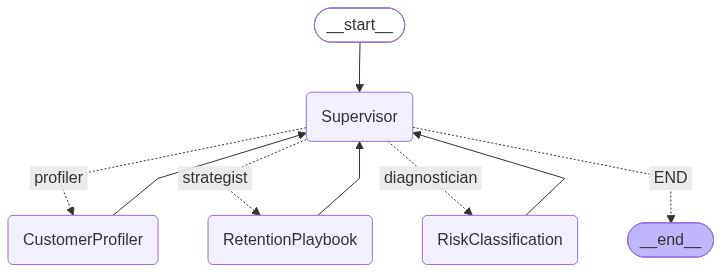

In [49]:
display(Image(graph.get_graph().draw_mermaid_png()))

### 6.4 Run the Multi-Agent System using Natural Language

To test the complete workflow, two helper functions were create
- `ask_agent()`
- `ask_agent_simple()`
  
These functions were used to validate the end-to-end behavior of the system by submitting natural language requests such as customer retention reviews and verifying the generated recommendations.endation.


#### 6.4.1 `ask_agent()`
Executes the workflow with a detailed execution trace. It displays each step of the process, including the outputs generated by the Customer Profiler, Churn Diagnostician, and Retention Strategist agents before showing the final retention recommendation.

In [50]:
def ask_agent(user_query: str):
    """
    Run the Customer Retention Intelligence System
    with full execution trace.
    """
    print("\n" + "="*70)
    print(f" User Query: {user_query}")
    print("="*70)

    initial_state = { "user_query": user_query}
    step = 0
    final_state = None

    for event in graph.stream(initial_state):
        for node_name, state in event.items():
            step += 1
            print(f"\nStep {step}: [{node_name}]")
            if node_name == "CustomerProfiler":
                print("   -> Customer profile generated")
                print("\n" + "_"*70)
                display(Markdown(state["customer_signals"]['content']))
                print("\n" + "_"*70)

            elif node_name == "RiskClassification":
                print("   -> Risk segment identified")
                print("\n" + "_"*70)
                display(Markdown(state["risk_assessment"]['content']))
                print("\n" + "_"*70)

            elif node_name == "RetentionPlaybook":
                print("   -> Retention strategy generated")
                print("\n" + "_"*70)
                display(Markdown(state["retention_plan"]['content']))
                print("\n" + "_"*70)

            elif node_name == "Supervisor":
                print("   -> Supervisor evaluating workflow state")

            final_state = state

    print("\n" + "_"*70)
    print(f" FINAL RETENTION DECISION ({step} graph steps)")
    print("_"*70 + "\n")

    if final_state and final_state.get("final_output"):
        display(Markdown(final_state["final_output"]))
    else:
        print("No final output generated.")

    return final_state

In [51]:
response = ask_agent("Give me retention report for the customer V001 to resolve his issue")


 User Query: Give me retention report for the customer V001 to resolve his issue

Step 1: [Supervisor]
   -> Supervisor evaluating workflow state

Step 2: [CustomerProfiler]
   -> Customer profile generated

______________________________________________________________________


Sub-Agent: Customer Profiler Agent

Customer Summary:
Anjali Desai is a Gold-tier customer who last made a purchase 67 days ago. She has low app engagement with 1 session per month, a 0.1 email open rate, and an NPS score of 3/10, alongside 4 support tickets in the last 30 days.

Customer ID: V001  
CLV Tier: Gold  
Signal Values:  
- Recency: 67 days  
- App Sessions/Month: 1  
- Email Open Rate: 0.1  
- NPS Score: 3/10  
- Support Tickets: 4


______________________________________________________________________

Step 3: [Supervisor]
   -> Supervisor evaluating workflow state

Step 4: [RiskClassification]
   -> Risk segment identified

______________________________________________________________________


Sub-Agent: Churn Diagnostician Agent

Matched Risk Segment: Support-Fatigued  
Next Best Action: ESCALATE  
Rules Confirmed:  
support_tickets >= 3 — actual: 4  
nps_score <= 4 — actual: 3  
email_open_rate < 0.20 — actual: 0.1  
Engagement Policy:  
No promotional content until the service issue is confirmed resolved


______________________________________________________________________

Step 5: [Supervisor]
   -> Supervisor evaluating workflow state

Step 6: [RetentionPlaybook]
   -> Retention strategy generated

______________________________________________________________________


Sub-Agent: Retention Strategist Agent

Next Best Action: ESCALATE  
Risk Segment: Support-Fatigued  
CLV Tier: Gold  
Treatment Steps:  
1. Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) - do not use generic automated messaging.  
2. Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience.  
3. Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team.  
Escalation Condition: Additional support ticket lodged within 7 days of initial outreach.  
Engagement Policy: No promotional content until the service issue is confirmed resolved.


______________________________________________________________________

Step 7: [Supervisor]
   -> Supervisor evaluating workflow state

______________________________________________________________________
 FINAL RETENTION DECISION (7 graph steps)
______________________________________________________________________



- Customer ID: V001  
- Risk Segment: Support-Fatigued  
- Next Best Action: ESCALATE  
- Action Rationale: Anjali Desai has a low NPS score of 3/10 and has submitted 4 support tickets in the last 30 days, indicating dissatisfaction and potential churn risk. Additionally, her email open rate of 0.1 is significantly below the threshold of 0.20, further supporting the need for immediate intervention.  
- Treatment Steps:  
  1. Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) - do not use generic automated messaging.  
  2. Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience.  
  3. Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team.  
- Engagement Policy: No promotional content until the service issue is confirmed resolved.  

#### 6.4.2 `ask_agent_simple()`
Executes the workflow and returns only the final retention decision, making it suitable for end-user interactions.

In [52]:
def ask_agent_simple(user_query: str):
    """Run the multi-agent system and display ONLY the final answer."""
    result = graph.invoke({"user_query": user_query})
    return Markdown(result['final_output'])

In [53]:
ask_agent_simple('Give me retention report for customer V002')

- Customer ID: V002  
- Risk Segment: Competitor-Switched  
- Next Best Action: NURTURE  
- Action Rationale: Suresh Kulkarni has been inactive for 105 days, which exceeds the 90-day threshold for recency. Additionally, their email open rate is only 0.06, which is below the 0.10 threshold, indicating low engagement.  
- Treatment Steps:  
  1. Send a win-back email on day 1 acknowledging the absence plainly, with a strong first-order incentive - 15% discount.  
  2. Follow up on day 10 with product highlights in the customer's top category, emphasising new arrivals since their last purchase.  
  3. Send a final win-back offer on day 25 - if no engagement across all three touches, move to passive monitoring only.  
- Engagement Policy: Win-back window closes after 180 days of inactivity - do not invest beyond this threshold.  

## 7. Validation run

### 7.1 Defining Helper Function

To make the solution easier to use, a reusable pipeline function is created. This function takes a customer ID as input, runs the complete multi-agent workflow, and returns the final retention recommendation generated by the Supervisor.

Using a single function simplifies testing and allows the same workflow to be executed efficiently for multiple customers in the test dataset.


In [54]:
import time

class PipelineExecutionError(RuntimeError):
    """Raised when the graph fails to produce a final_output after retrying."""


def run_pipeline(customer_id: str, max_attempts: int = 2) -> dict:
    """Invoke the full multi-agent graph for a single customer ID.

    Args:
        customer_id: e.g. 'V001' or 'T001'.
        max_attempts: number of attempts before giving up (handles transient API errors).

    Returns:
        The final MultiAgentState dict, including 'final_output' and 'provenance_record'.
    """
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            final_state = graph.invoke(MultiAgentState({"customer_id": customer_id}))
            if not final_state.get("final_output"):
                raise PipelineExecutionError(
                    f"Graph completed without producing final_output for '{customer_id}'."
                )
            return final_state
        except Exception as e:  # transient network/API errors, tool errors, etc.
            last_error = e
            if attempt < max_attempts:
                time.sleep(2 * attempt)
                continue
    raise PipelineExecutionError(
        f"run_pipeline failed for '{customer_id}' after {max_attempts} attempt(s): {last_error}"
    )

In [55]:
# Quick sanity check 
final_state = run_pipeline("V001")
print(final_state['final_output'])

- Customer ID: V001  
- Risk Segment: Support-Fatigued  
- Next Best Action: ESCALATE  
- Action Rationale: Anjali Desai has a low NPS score of 3/10 and has submitted 4 support tickets in the last 30 days, indicating dissatisfaction with service. Additionally, her email open rate is only 10%, which reflects low engagement.  
- Treatment Steps:  
  1. Assign to CRM specialist for a personal call within 24 hours (Gold/Platinum tier) - do not use generic automated messaging.  
  2. Credit 500 goodwill points to the account immediately as a service recovery gesture, framed as a thank-you for the customer's patience.  
  3. Monitor NPS score and support ticket count at day 7 and day 14 - if NPS has not improved or a new ticket is raised, re-escalate to senior CRM team.  
- Engagement Policy: No promotional content until the service issue is confirmed resolved.  


### 7.2 Run on the Validation Set

Before evaluating the system on the test dataset, the completed multi-agent workflow was validated using all 10 validation customers (V001-V010). This step helped verify that the Customer Profiler, Churn Diagnostician, Retention Strategist, and Supervisor agents were working together correctly and producing the expected outputs.

The generated results were compared against the provided **validation\_results.csv** file to assess accuracy and identify any areas for improvement. Only after satisfactory validation performance was achieved was the system considered ready for execution on the test dataset.

In [56]:
validation_customers[0]

{'customer_id': 'V001',
 'name': 'Anjali Desai',
 'clv_tier': 'Gold',
 'recency_days': 67,
 'app_sessions_mo': 1,
 'email_open_rate': 0.1,
 'nps_score': 3,
 'support_tickets': 4}

In [57]:
# Generated Validation
validation_ids = [customer["customer_id"] for customer in validation_customers]
validation_rows = []
validation_provenance = {}

for cid in validation_ids:
    state = run_pipeline(cid)
    validation_rows.append({"customer_id": cid, "agent_response": state['final_output']})
    validation_provenance[cid] = state["provenance_record"]
    print(f"--- {cid} done ---")

validation_generated_df = pd.DataFrame(validation_rows)
validation_generated_df.to_csv(f"{DATA_DIR}/validation_generated.csv", index=False)
validation_generated_df

--- V001 done ---
--- V002 done ---
--- V003 done ---
--- V004 done ---
--- V005 done ---
--- V006 done ---
--- V007 done ---
--- V008 done ---
--- V009 done ---
--- V010 done ---


,customer_id,agent_response
0,V001,- Customer ID: V001 \n- Risk Segment: Support...
1,V002,- Customer ID: V002 \n- Risk Segment: Competi...
2,V003,- Customer ID: V003 \n- Risk Segment: Support...
3,V004,- Customer ID: V004 \n- Risk Segment: Disenga...
4,V005,- Customer ID: V005 \n- Risk Segment: Healthy...
5,V006,- Customer ID: V006 \n- Risk Segment: Competi...
6,V007,- Customer ID: V007 \n- Risk Segment: Disenga...
7,V008,- Customer ID: V008 \n- Risk Segment: Healthy...
8,V009,- Customer ID: V009 \n- Risk Segment: Disenga...
9,V010,- Customer ID: V010 \n- Risk Segment: Support...


In [59]:
# Actual validation
validation_results

,customer_id,reference_agent_response
0,V001,- Customer ID: V001\n- Risk Segment: Support-F...
1,V002,- Customer ID: V002\n- Risk Segment: Competito...
2,V003,- Customer ID: V003\n- Risk Segment: Support-F...
3,V004,- Customer ID: V004\n- Risk Segment: Disengage...
4,V005,- Customer ID: V005\n- Risk Segment: Healthy\n...
5,V006,- Customer ID: V006\n- Risk Segment: Competito...
6,V007,- Customer ID: V007\n- Risk Segment: Disengage...
7,V008,- Customer ID: V008\n- Risk Segment: Healthy\n...
8,V009,- Customer ID: V009\n- Risk Segment: Disengage...
9,V010,- Customer ID: V010\n- Risk Segment: Support-F...


### 7.3 Combining `agent_response` and `reference_agent_response`

In [60]:
validation_eval_df = validation_generated_df.merge(
    validation_results,
    on="customer_id",
    how="left"
)

validation_eval_df.head()

,customer_id,agent_response,reference_agent_response
0,V001,- Customer ID: V001 \n- Risk Segment: Support...,- Customer ID: V001\n- Risk Segment: Support-F...
1,V002,- Customer ID: V002 \n- Risk Segment: Competi...,- Customer ID: V002\n- Risk Segment: Competito...
2,V003,- Customer ID: V003 \n- Risk Segment: Support...,- Customer ID: V003\n- Risk Segment: Support-F...
3,V004,- Customer ID: V004 \n- Risk Segment: Disenga...,- Customer ID: V004\n- Risk Segment: Disengage...
4,V005,- Customer ID: V005 \n- Risk Segment: Healthy...,- Customer ID: V005\n- Risk Segment: Healthy\n...


## 8. Evaluation

After generating responses for the validation customers, the results were evaluated against the reference outputs provided in **validation\_results.csv**.

The evaluation process consisted of three steps:

1. Generate retention recommendations for all validation customers (**V001-V010**) using the completed multi-agent system.
2. Match the generated responses with the reference responses using the **customer\_id** field.
3. Use the provided **LLM-as-Judge** prompts to assess the quality of the generated outputs. One evaluation focused on the accuracy of the **Risk Segment** and **Next Best Action**, while the other evaluated the quality of the **Action Rationale** and **Treatment Steps**.

This evaluation helped measure how closely the system's outputs aligned with the expected results and provided insights for further refinement before running the final test set.


### 8.1 Grounding & Hallucination Verification (code-based, not LLM-judged)

This is the executable evidence the v1 submission was missing. For every validation customer, `verify_grounding` checks that the numeric/categorical facts quoted in the final decision text actually match the `raw_data` captured from each tool call — i.e. it re-derives, from code, whether the Customer Signals in the final answer really did come from `fetch_customer_record`, and whether Risk Segment/NBA really did come from `classify_risk_segment`.

In [61]:
def verify_grounding(final_output: str, provenance_record: dict) -> list[str]:
    """Cross-check numeric/categorical facts quoted in final_output against the raw tool
    data captured in provenance_record. Returns a list of mismatch descriptions (empty
    list == fully grounded).
    """
    issues = []
    signals = provenance_record["customer_signals"]["raw_data"]
    risk = provenance_record["risk_assessment"]["raw_data"]
    
    if signals.get("customer_id") and signals["customer_id"] not in final_output:
        issues.append(f"customer_id '{signals['customer_id']}' not found in final_output")
    if risk.get("segment") and risk["segment"] not in final_output:
        issues.append(f"segment '{risk['segment']}' not found in final_output")
    if risk.get("decision") and risk["decision"] not in final_output:
        issues.append(f"next best action '{risk['decision']}' not found in final_output")
    
    return issues

In [62]:
grounding_rows = []
for cid in validation_ids:
    row = validation_generated_df.loc[validation_generated_df["customer_id"] == cid].iloc[0]
    issues = verify_grounding(row["agent_response"], validation_provenance[cid])
    grounding_rows.append({
        "customer_id": cid,
        "profiler_tool_verified": validation_provenance[cid]["customer_signals"]["tool_call_verified"],
        "diagnostician_tool_verified": validation_provenance[cid]["risk_assessment"]["tool_call_verified"],
        "strategist_tool_verified": validation_provenance[cid]["retention_plan"]["tool_call_verified"],
        "grounding_issues": issues,
        "fully_grounded": len(issues) == 0,
    })

grounding_df = pd.DataFrame(grounding_rows)
grounding_df

,customer_id,profiler_tool_verified,diagnostician_tool_verified,strategist_tool_verified,grounding_issues,fully_grounded
0,V001,True,True,True,[],True
1,V002,True,True,True,[],True
2,V003,True,True,True,[],True
3,V004,True,True,True,[],True
4,V005,True,True,True,[],True
5,V006,True,True,True,[],True
6,V007,True,True,True,[],True
7,V008,True,True,True,[],True
8,V009,True,True,True,[],True
9,V010,True,True,True,[],True


In [63]:
print(f"Verified tool calls (all 3 agents) : "
      f"{(grounding_df[['profiler_tool_verified','diagnostician_tool_verified','strategist_tool_verified']].all(axis=1)).sum()}/{len(grounding_df)}")
print(f"Fully grounded final responses      : {grounding_df['fully_grounded'].sum()}/{len(grounding_df)}")
if not grounding_df["fully_grounded"].all():
    print("\nCustomers with grounding issues:")
    display(grounding_df[~grounding_df["fully_grounded"]][["customer_id", "grounding_issues"]])

Verified tool calls (all 3 agents) : 10/10
Fully grounded final responses      : 10/10


 ### 8.2 LLM-as-Judge

In [64]:
JUDGE_SEGMENT_PROMPT = ChatPromptTemplate.from_template(""" 
You are an evaluator for a CXM retention AI system. 
Your job is to extract two fields from each response and compare them. 

AGENT RESPONSE: 
{agent_response} 

REFERENCE RESPONSE: 
{reference_response} 

Extract the following fields from BOTH responses: 
1. Risk Segment: Support-Fatigued, Disengaged, Competitor-Switched, or Healthy 
2. Next Best Action: ESCALATE, NURTURE, or HOLD 

Then compare whether the agent's values match the reference values. 

Respond in this exact JSON format and nothing else: 
{{ 
"agent_risk_segment": "<value or MISSING>", 
"agent_next_best_action": "<value or MISSING>", 
"reference_risk_segment": "<value>", 
"reference_next_best_action": "<value>", 
"risk_segment_match": true or false, 
"next_best_action_match": true or false 
}}

Respond with raw JSON only.

Do NOT wrap the response in:
- ```json
- ```
- markdown
- explanations

Return only the JSON object.
""")

JUDGE_QUALITY_PROMPT = ChatPromptTemplate.from_template(""" 
You are an expert evaluator for a CXM retention AI system. 
Evaluate the AGENT RESPONSE against the REFERENCE RESPONSE on two dimensions. 

AGENT RESPONSE: 
{agent_response} 

REFERENCE RESPONSE: 
{reference_response} 

GRADING CRITERIA: 
GOOD = The response correctly addresses the dimension with no significant gaps or errors. 
BAD = The response is missing key elements, contains incorrect information, or is too generic. 

Dimension 1 — Action Rationale: 
Does the agent's rationale cite actual customer signal values, such as specific numbers? 
Is it grounded in the customer's data rather than generic statements? 

Dimension 2 — Treatment Steps: 
Do the agent's treatment steps align with the reference playbook? 
Are all major steps present and correctly described? 

Respond in this exact JSON format and nothing else: 
{{ 
"action_rationale_quality": "<GOOD or BAD>", 
"action_rationale_justification": "<one sentence>", 
"treatment_steps_quality": "<GOOD or BAD>", 
"treatment_steps_justification": "<one sentence>" 
}} 

Respond with raw JSON only.
Do NOT wrap the response in:
- ```json
- ```
- markdown
- explanations

Return only the JSON object.
""")

print("Judge prompts ready.")

Judge prompts ready.


In [65]:
def judge_segment_and_nba(agent_response, reference_response):
    """
    LLM-based evaluator to whether the agent correctly identified the customer's Risk Segment 
    and Next Best Action (NBA) when compared with the reference response.
    """
    chain = JUDGE_SEGMENT_PROMPT | llm
    response = chain.invoke({"agent_response": agent_response, "reference_response": reference_response})
    # print(response.content)
    return json.loads(response.content)

In [66]:
def judge_quality(agent_response, reference_response):
    """
    Evaluate the quality of the agent's response against the reference response using an LLM-as-Judge approach.
    The function assesses two key aspects of the retention recommendation:
    the quality of the Action Rationale and the quality of the Treatment Steps. 
    The evaluation determines whether the rationale is grounded in actual customer data and whether the 
    proposed treatment plan aligns with the expected retention playbook.
    """
    chain = JUDGE_QUALITY_PROMPT | llm
    response = chain.invoke({"agent_response": agent_response, "reference_response": reference_response})
    # print(response.content)
    return json.loads(response.content)

In [67]:
judge_rows = []
for _, row in validation_eval_df.iterrows():
    seg_result = judge_segment_and_nba(row["agent_response"], row["reference_agent_response"])
    qual_result = judge_quality(row["agent_response"], row["reference_agent_response"])
    judge_rows.append({"customer_id": row["customer_id"], **seg_result, **qual_result})

judge_df = pd.DataFrame(judge_rows)
judge_df

,customer_id,agent_risk_segment,agent_next_best_action,reference_risk_segment,reference_next_best_action,risk_segment_match,next_best_action_match,action_rationale_quality,action_rationale_justification,treatment_steps_quality,treatment_steps_justification
0,V001,Support-Fatigued,ESCALATE,Support-Fatigued,ESCALATE,True,True,GOOD,The agent's rationale cites specific customer ...,GOOD,The agent's treatment steps align with the ref...
1,V002,Competitor-Switched,NURTURE,Competitor-Switched,NURTURE,True,True,GOOD,The agent's rationale cites specific customer ...,GOOD,The agent's treatment steps align with the ref...
2,V003,Support-Fatigued,ESCALATE,Support-Fatigued,ESCALATE,True,True,GOOD,The agent's rationale cites specific customer ...,GOOD,The agent's treatment steps align with the ref...
3,V004,Disengaged,NURTURE,Disengaged,NURTURE,True,True,GOOD,The agent's rationale cites specific customer ...,BAD,The agent's treatment steps lack key actions f...
4,V005,Healthy,HOLD,Healthy,HOLD,True,True,BAD,The agent response omits key customer signal v...,GOOD,The agent's treatment steps align with the ref...
5,V006,Competitor-Switched,NURTURE,Competitor-Switched,NURTURE,True,True,GOOD,The agent's rationale cites specific customer ...,GOOD,The agent's treatment steps align with the ref...
6,V007,Disengaged,NURTURE,Disengaged,NURTURE,True,True,GOOD,The agent's rationale cites specific customer ...,BAD,The agent's treatment steps lack key actions s...
7,V008,Healthy,HOLD,Healthy,HOLD,True,True,BAD,"The agent response omits the email open rate, ...",GOOD,The agent's treatment steps align fully with t...
8,V009,Disengaged,NURTURE,Disengaged,NURTURE,True,True,GOOD,The agent's rationale cites specific customer ...,BAD,The agent's treatment steps lack key actions f...
9,V010,Support-Fatigued,ESCALATE,Support-Fatigued,ESCALATE,True,True,GOOD,The agent's rationale cites specific customer ...,GOOD,The agent's treatment steps align with the ref...


In [69]:
n = len(judge_df)
seg_acc = judge_df["risk_segment_match"].sum() / n
nba_acc = judge_df["next_best_action_match"].sum() / n
rationale_good = (judge_df["action_rationale_quality"] == "GOOD").sum()
steps_good = (judge_df["treatment_steps_quality"] == "GOOD").sum()

print(f"Validation set size:                {n}")
print(f"Risk Segment match accuracy:         {seg_acc:.0%}")
print(f"Next Best Action match accuracy:     {nba_acc:.0%}")
print(f"Action Rationale judged GOOD:        {rationale_good}/{n}")
print(f"Treatment Steps judged GOOD:         {steps_good}/{n}")
print()
if seg_acc == 1.0 and nba_acc == 1.0:
    print("Validation results are satisfactory — proceeding to the test set.")
else:
    print("Review mismatches above before proceeding to the test set.")


Validation set size:                10
Risk Segment match accuracy:         100%
Next Best Action match accuracy:     100%
Action Rationale judged GOOD:        8/10
Treatment Steps judged GOOD:         7/10

Validation results are satisfactory — proceeding to the test set.


### 8.3 Tool Invocation Log (agent traceability)

Explicit, per-customer confirmation of which tool each sub-agent actually called - this is the artifact an evaluator can scan to confirm tool-enabled agent architecture, without re-reading the graph code.

In [70]:
trace_rows = []
for cid, prov in validation_provenance.items():
    for stage, key in [("Profile", "customer_signals"), ("Diagnose", "risk_assessment"), ("Recommend", "retention_plan")]:
        trace_rows.append({
            "customer_id": cid,
            "stage": stage,
            "source_agent": prov[key]["source_agent"],
            "tool_name": prov[key]["tool_name"],
            "tool_call_verified": prov[key]["tool_call_verified"],
        })

trace_df = pd.DataFrame(trace_rows)
print(f"Verified tool calls: {trace_df['tool_call_verified'].sum()}/{len(trace_df)}")
trace_df


Verified tool calls: 30/30


,customer_id,stage,source_agent,tool_name,tool_call_verified
0,V001,Profile,Customer Profiler Agent,fetch_customer_record,True
1,V001,Diagnose,Churn Diagnostician Agent,classify_risk_segment,True
2,V001,Recommend,Retention Strategist Agent,recommend_retention_action,True
3,V002,Profile,Customer Profiler Agent,fetch_customer_record,True
4,V002,Diagnose,Churn Diagnostician Agent,classify_risk_segment,True
5,V002,Recommend,Retention Strategist Agent,recommend_retention_action,True
6,V003,Profile,Customer Profiler Agent,fetch_customer_record,True
7,V003,Diagnose,Churn Diagnostician Agent,classify_risk_segment,True
8,V003,Recommend,Retention Strategist Agent,recommend_retention_action,True
9,V004,Profile,Customer Profiler Agent,fetch_customer_record,True


### 9. Test run


After validating and refining the multi-agent workflow using the validation dataset, the finalized system is executed on the **test customer records (T001–T010)**.

For each test customer:

1. The customer ID is provided to the Supervisor.
2. The Supervisor orchestrates the complete workflow.
3. The Customer Profiler creates the customer profile.
4. The Churn Diagnostician identifies the risk segment and Next Best Action.
5. The Retention Strategist retrieves the relevant playbook and generates the treatment plan.
6. The Supervisor combines all outputs and produces the final retention recommendation.

The final responses for all 10 test customers are collected and saved into **submission.csv** with the required format:

* **customer\_id**: Test customer identifier (T001–T010)
* **agent\_response**: Final retention recommendation generated by the multi-agent system

The resulting **submission.csv** contains exactly **10 rows and 2 columns**, representing the final output of the Customer Retention Intelligence System for evaluation and submission.


In [71]:
test_customers[0]

{'customer_id': 'T001',
 'name': 'Alok Saxena',
 'clv_tier': 'Platinum',
 'recency_days': 80,
 'app_sessions_mo': 1,
 'email_open_rate': 0.07,
 'nps_score': 3,
 'support_tickets': 4}

In [73]:
# Generated submission on test
test_ids = [customer["customer_id"] for customer in test_customers]
test_rows = []

for cid in test_ids:
    state = run_pipeline(cid)
    test_rows.append({"customer_id": cid, "agent_response": state['final_output']})
    print(f"--- {cid} done ---")

test_generated_df = pd.DataFrame(test_rows)
test_generated_df.to_csv(f"{DATA_DIR}/submission.csv", index=False)
test_generated_df

--- T001 done ---
--- T002 done ---
--- T003 done ---
--- T004 done ---
--- T005 done ---
--- T006 done ---
--- T007 done ---
--- T008 done ---
--- T009 done ---
--- T010 done ---


,customer_id,agent_response
0,T001,- Customer ID: T001 \n- Risk Segment: Support...
1,T002,- Customer ID: T002 \n- Risk Segment: Competi...
2,T003,- Customer ID: T003 \n- Risk Segment: Healthy...
3,T004,- Customer ID: T004 \n- Risk Segment: Disenga...
4,T005,- Customer ID: T005 \n- Risk Segment: Support...
5,T006,- Customer ID: T006 \n- Risk Segment: Support...
6,T007,- Customer ID: T007 \n- Risk Segment: Healthy...
7,T008,- Customer ID: T008 \n- Risk Segment: Competi...
8,T009,- Customer ID: T009 \n- Risk Segment: Disenga...
9,T010,- Customer ID: T010 \n- Risk Segment: Competi...


## 10. Conclusion

This project developed a multi-agent customer retention system using `LangGraph`, `LangChain`, Azure `OpenAI`, and `ChromaDB`. The system uses multiple specialized agents to analyze customer data, identify churn risk, and recommend retention strategies. 

By combining agent orchestration, business rules, and RAG-based playbook retrieval, it generates structured and actionable retention recommendations in an automated and scalable ma decisions.